# MODULE 1: USER PERSONA CLUSTERING

> **Mục tiêu:** Phân cụm người dùng (User Persona) dựa trên hành vi nghe nhạc để hiểu rõ hơn về các nhóm đối tượng và đưa ra chiến lược cá nhân hóa phù hợp.


In [1]:
# ========== 0. CÀI ĐẶT THƯ VIỆN ==========
!pip install pyspark openpyxl -q

In [2]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import (
    col, hour, to_date, count, sum as spark_sum,
    when, approx_count_distinct, expr, avg, stddev, lit, log2, 
    datediff, current_date, max as spark_max, min as spark_min,
    lag, unix_timestamp, from_unixtime, struct, collect_list
)
from pyspark import StorageLevel
from pyspark.sql.window import Window
from pyspark.ml.feature import VectorAssembler, StandardScaler, PCA
from pyspark.ml.clustering import KMeans, BisectingKMeans, GaussianMixture
from pyspark.ml.evaluation import ClusteringEvaluator
from pyspark.ml.fpm import FPGrowth
from pyspark.ml.functions import vector_to_array
import pyspark.sql.functions as F
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import seaborn as sns
import numpy as np
import json
import time
import os
import pickle
import pandas as pd
from pyspark.sql.functions import col

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)
print("Imports OK")

Imports OK


1. KHỞI TẠO SPARK SESSION 

In [3]:
spark = SparkSession.builder \
    .appName("User Persona Clustering") \
    .config("spark.sql.adaptive.enabled", "true") \
    .config("spark.sql.adaptive.coalescePartitions.enabled", "true") \
    .config("spark.sql.autoBroadcastJoinThreshold", "50m") \
    .config("spark.sql.shuffle.partitions", "400") \
    .config("spark.executor.memory", "14g") \
    .config("spark.driver.memory", "14g") \
    .config("spark.memory.fraction", "0.8") \
    .config("spark.memory.storageFraction", "0.4") \
    .config("spark.serializer", "org.apache.spark.serializer.KryoSerializer") \
    .config("spark.sql.execution.arrow.pyspark.enabled", "true")\
    .getOrCreate()

spark.sparkContext.setLogLevel("WARN")
print("Spark ok")

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/04/21 12:50:06 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Spark ok


2. ĐỌC DỮ LIỆU
> Đọc và gộp dữ liệu từ các thư mục dạng `.csv` và `.xlsx` (sử dụng kết hợp PySpark & Pandas).

In [4]:
print("\n" + "="*60)
print("PHASE 1: DATA LOADING")
print("="*60)

path_cleardata = "/kaggle/input/datasets/js042710/second3t1k/CLEARDATA/CLEARDATA"
path_data_dm = "/kaggle/input/datasets/js042710/second3t1k/data DM/data DM"

def load_mixed_data(spark, folder_path):
    """
    Hàm tự động quét và đọc cả file CSV (bằng Spark) và XLSX (bằng Pandas -> Spark)
    """
    print(f"Đang xử lý thư mục: {folder_path}")
    
    # 1. Đọc TẤT CẢ file .csv bằng Spark (bỏ qua các file khác)
    print("  -> Đang nạp các file .csv...")
    df_csv = spark.read.option("header", "true") \
        .option("inferSchema", "false") \
        .option("quote", '"').option("escape", '"') \
        .option("pathGlobFilter", "*.csv") \
        .option("recursiveFileLookup", "true") \
        .csv(folder_path)
    
    # 2. Tìm và đọc các file .xlsx
    excel_spark_dfs = []
    for root, dirs, files in os.walk(folder_path):
        for file in files:
            if file.endswith(".xlsx") and not file.startswith("~"):
                file_path = os.path.join(root, file)
                print(f"  -> Đang nạp Excel file: {file}")
                try:
                    # Đọc bằng Pandas, ép kiểu tất cả về chuỗi (string) để khớp với df_csv
                    pdf = pd.read_excel(file_path, dtype=str, engine='openpyxl')
                    # Xóa các cột Unnamed (thường sinh ra do file Excel có cột rỗng)
                    pdf = pdf.loc[:, ~pdf.columns.str.contains('^Unnamed')]
                    # Chuyển thành Spark DataFrame
                    sdf = spark.createDataFrame(pdf)
                    excel_spark_dfs.append(sdf)
                except Exception as e:
                    print(f"     [LỖI] Không thể đọc {file}: {e}")
                    
    # 3. Gộp CSV và các file Excel lại với nhau
    final_df = df_csv
    for sdf in excel_spark_dfs:
        final_df = final_df.unionByName(sdf, allowMissingColumns=True)
        
    return final_df

# Gọi hàm load dữ liệu
df_clear = load_mixed_data(spark, path_cleardata)
df_dm = load_mixed_data(spark, path_data_dm)

# Gộp toàn bộ dữ liệu từ 2 thư mục
df = df_clear.unionByName(df_dm, allowMissingColumns=True)
df_clear.unpersist()
df_dm.unpersist()

# Chia lại phân vùng để tối ưu tính toán song song
df = df.repartition(100)

print(f"\nNạp dữ liệu thành công! Tổng số dòng (Total records): {df.count()}")


PHASE 1: DATA LOADING
Đang xử lý thư mục: /kaggle/input/datasets/js042710/second3t1k/CLEARDATA/CLEARDATA
  -> Đang nạp các file .csv...
  -> Đang nạp Excel file: clean_21.1.2026.listens.xlsx
Đang xử lý thư mục: /kaggle/input/datasets/js042710/second3t1k/data DM/data DM
  -> Đang nạp các file .csv...
  -> Đang nạp Excel file: clean_02.03.2026.listens.xlsx


26/04/21 12:52:50 WARN TaskSetManager: Stage 2 contains a task of very large size (1315 KiB). The maximum recommended task size is 1000 KiB.



Nạp dữ liệu thành công! Tổng số dòng (Total records): 166920444


In [5]:
# Thêm sau khi đọc dữ liệu
from pyspark.sql.functions import count, when, col
print("\n" + "="*60)
print("DATA VALIDATION")
print("="*60)

required_columns = ["user_id", "track_name", "artist_name", "timestamp"]


# Đếm null cho tất cả các cột trong 1 lần duyệt duy nhất
exprs = [count(when(col(c).isNull(), c)).alias(c) for c in required_columns if c in df.columns]
null_counts = df.agg(*exprs).collect()[0].asDict()

for c, count_val in null_counts.items():
    if count_val > 0:
        print(f"  Column '{c}': {count_val} null values")



DATA VALIDATION


26/04/21 12:55:31 WARN TaskSetManager: Stage 8 contains a task of very large size (1315 KiB). The maximum recommended task size is 1000 KiB.


  Column 'track_name': 2011 null values
  Column 'artist_name': 2877 null values
  Column 'timestamp': 750 null values


## 3. Tiền Xử Lý Dữ Liệu (Preprocessing)

> Thực hiện các bước làm sạch dữ liệu:
> - Lọc bỏ các dòng bị thiếu `null`.
> - Xử lý kiểu dữ liệu `Timestamp`.
> - Trích xuất các thuộc tính thời gian như `hour`, `date`, `unix_ts`.


In [6]:
print("\n" + "="*60)
print("PHASE 2: DATA PREPROCESSING")
print("="*60)

required_columns = ["user_id", "track_name", "artist_name", "timestamp"]

if "skip" in df.columns:
    required_columns.append("skip")
if "duration" in df.columns:
    required_columns.append("duration")

df = df.select(*[col(c) for c in required_columns if c in df.columns])
df.cache()

df_with_ts = df.withColumn("ts", expr("try_cast(timestamp as timestamp)")) \
               .dropna(subset=["ts"]) \
               .withColumn("hour", hour(col("ts"))) \
               .withColumn("date", to_date(col("ts"))) \
               .withColumn("unix_ts", unix_timestamp(col("ts")))

df_processed = df_with_ts.select("user_id", "track_name", "artist_name", "hour", "date", "unix_ts") \
                         .dropna(subset=["track_name", "artist_name"])

if "skip" in df.columns:
    df_processed = df_processed.withColumn("skip", col("skip").cast("int"))
if "duration" in df.columns:
    df_processed = df_processed.withColumn("duration", col("duration").cast("double"))

df_processed.cache()
df.unpersist()
print(f"Records sau xử lý: {df_processed.count()}")


PHASE 2: DATA PREPROCESSING


26/04/21 13:00:18 WARN TaskSetManager: Stage 14 contains a task of very large size (1315 KiB). The maximum recommended task size is 1000 KiB.


Records sau xử lý: 166917541


## 4. Phân Tích Dữ Liệu Khám Phá (EDA)

> Phân tích chuyên sâu về phân phối dữ liệu:
> - Lượt nghe của từng User (Histogram, Boxplot).
> - Tổng số lượt nghe theo khung giờ.
> - Tỷ lệ bỏ qua bài hát (Skip Rate).



PHASE 3: EXPLORATORY DATA ANALYSIS (EDA)



[EDA] Phân phối lượt nghe theo User:
  - 25% users nghe dưới: 73 bài
  - Median (50% users): 535 bài
  - 75% users nghe dưới: 1705 bài
  - Top 10% (90th percentile) nghe trên: 4101 bài
  - Top 1% (99th percentile) nghe trên: 5272810 bài


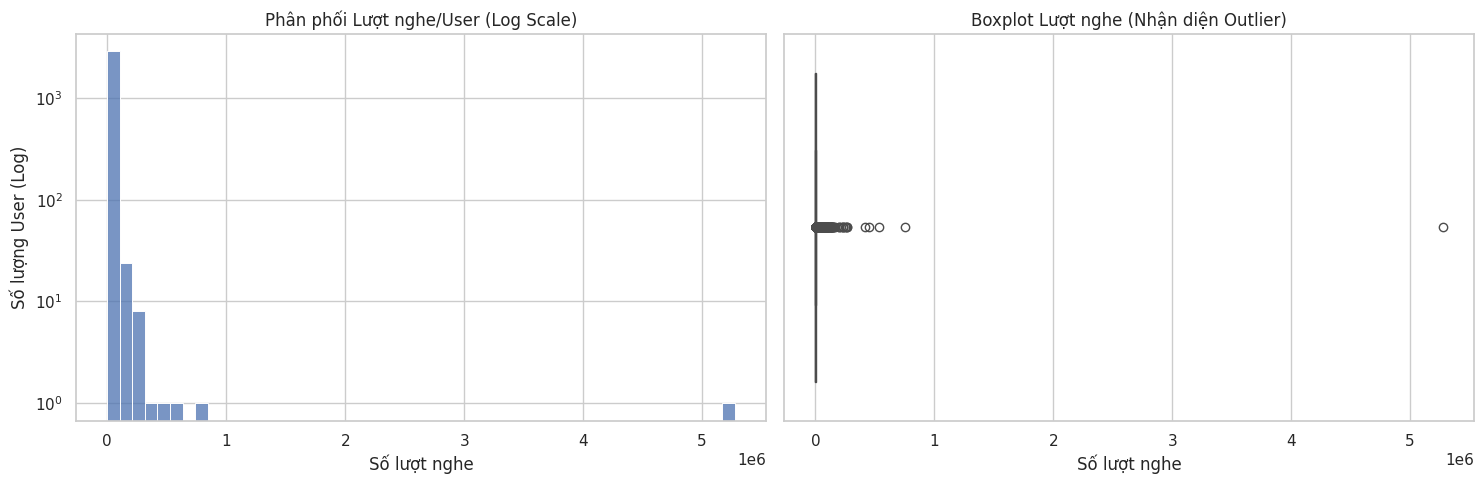

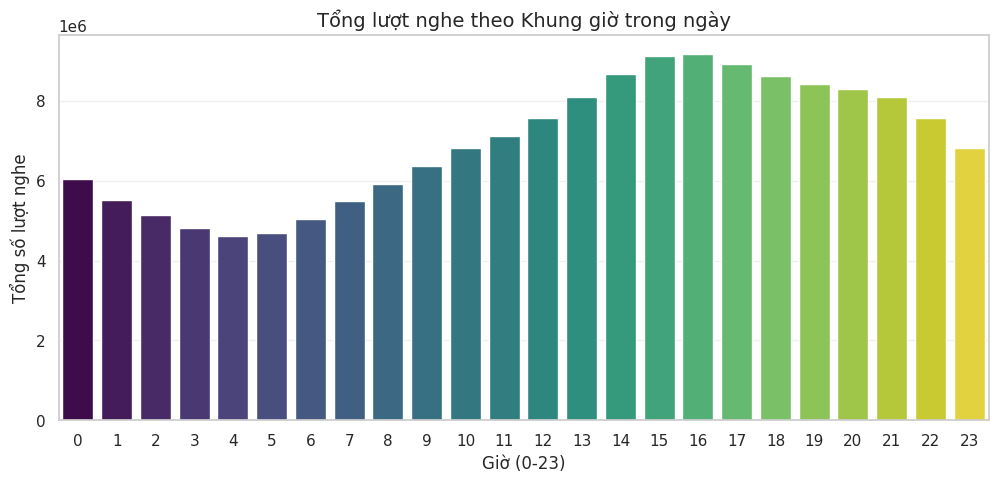


EDA Hoàn tất. Chuyển sang Feature Engineering.


In [7]:
print("\n" + "="*60)
print("PHASE 3: EXPLORATORY DATA ANALYSIS (EDA)")
print("="*60)

# 1. Thống kê tổng quan (User Activity Distribution)
# Tính số log mỗi user
user_activity = df_processed.groupBy("user_id").agg(F.count("*").alias("play_count"))

# Tính các mốc phân vị để xem độ lệch (skewness)
quantiles = user_activity.approxQuantile("play_count", [0.25, 0.5, 0.75, 0.9, 0.99], 0.01)
print("\n[EDA] Phân phối lượt nghe theo User:")
print(f"  - 25% users nghe dưới: {quantiles[0]:.0f} bài")
print(f"  - Median (50% users): {quantiles[1]:.0f} bài")
print(f"  - 75% users nghe dưới: {quantiles[2]:.0f} bài")
print(f"  - Top 10% (90th percentile) nghe trên: {quantiles[3]:.0f} bài")
print(f"  - Top 1% (99th percentile) nghe trên: {quantiles[4]:.0f} bài")

# Vẽ biểu đồ phân phối (sử dụng Pandas cho một sample để khỏi tràn RAM)
sample_activity = user_activity.sample(fraction=min(0.1, 10000/user_activity.count()), seed=42).toPandas()

fig, ax = plt.subplots(1, 2, figsize=(15, 5))

# Biểu đồ Histogram có scale Log
sns.histplot(sample_activity['play_count'], bins=50, ax=ax[0])
ax[0].set_yscale('log')
ax[0].set_title('Phân phối Lượt nghe/User (Log Scale)')
ax[0].set_xlabel('Số lượt nghe')
ax[0].set_ylabel('Số lượng User (Log)')

# Boxplot để thấy rõ Outliers
sns.boxplot(x=sample_activity['play_count'], ax=ax[1])
ax[1].set_title('Boxplot Lượt nghe (Nhận diện Outlier)')
ax[1].set_xlabel('Số lượt nghe')

plt.tight_layout()
plt.show()

# 2. Phân tích hành vi theo Giờ (Time-of-day Analysis)
hour_distribution = df_processed.groupBy("hour").agg(F.count("*").alias("plays")).orderBy("hour").toPandas()

plt.figure(figsize=(12, 5))
sns.barplot(data=hour_distribution, x='hour', y='plays', hue='hour', palette="viridis", legend=False)
plt.title('Tổng lượt nghe theo Khung giờ trong ngày', fontsize=14)
plt.xlabel('Giờ (0-23)')
plt.ylabel('Tổng số lượt nghe')
plt.xticks(range(0, 24))
plt.grid(axis='y', alpha=0.3)
plt.show()

# 3. Phân tích Tỷ lệ Skip (Nếu có)
if "skip" in df_processed.columns:
    skip_stats = df_processed.groupBy("skip").agg(F.count("*").alias("count")).toPandas()
    total_plays = skip_stats['count'].sum()
    skip_stats['percentage'] = (skip_stats['count'] / total_plays) * 100
    
    print("\n[EDA] Phân phối Hành vi Skip:")
    print(skip_stats.to_string(index=False))
    
    plt.figure(figsize=(6, 6))
    plt.pie(skip_stats['count'], labels=['Not Skipped', 'Skipped'], autopct='%1.1f%%', colors=['#66b3ff', '#ff9999'])
    plt.title('Tỷ lệ Skip tổng thể')
    plt.show()

print("\nEDA Hoàn tất. Chuyển sang Feature Engineering.")


## 5. Trích Xuất Đặc Trưng (Feature Engineering)

> Xây dựng các nhóm đặc trưng nâng cao nhằm phục vụ mô hình học máy:
> - **Volume & Time Features**: Khối lượng lượt nghe và các khung giờ quen thuộc.
> - **Session Analysis**: Chiều sâu và thời lượng phiên nghe nhạc.
> - **Shannon Entropy**: Độ đa dạng trong sở thích nghệ sĩ và thời gian nghe.


In [8]:
print("\n" + "="*60)
print("PHASE 3: FEATURE ENGINEERING")
print("="*60)

# ---- Build danh sách agg expressions động ----
agg_exprs = [
    # Volume metrics
    F.count("*").alias("total_listens"),
    F.approx_count_distinct("track_name", rsd=0.05).alias("unique_tracks"),
    F.approx_count_distinct("artist_name", rsd=0.05).alias("unique_artists"),
    F.approx_count_distinct("date", rsd=0.05).alias("active_days"),

    # Time-based listening
    F.sum(F.when((F.col("hour") >= 22) | (F.col("hour") <= 4), 1).otherwise(0)).alias("night_listens"),
    F.sum(F.when((F.col("hour") >= 5)  & (F.col("hour") <= 11), 1).otherwise(0)).alias("morning_listens"),
    F.sum(F.when((F.col("hour") >= 12) & (F.col("hour") <= 17), 1).otherwise(0)).alias("afternoon_listens"),
    F.sum(F.when((F.col("hour") >= 18) & (F.col("hour") <= 21), 1).otherwise(0)).alias("evening_listens"),

    # Time statistics
    F.avg("hour").alias("avg_listen_hour"),
    F.stddev("hour").alias("hour_std"),
]

# Đưa skip và duration VÀO TRONG .agg() thay vì dùng withColumn sau
if "skip" in df_processed.columns:
    agg_exprs.append(
        F.sum(F.when(F.col("skip") == 1, 1).otherwise(0)).alias("total_skips")
    )

if "duration" in df_processed.columns:
    agg_exprs.append(
        F.avg(F.when(F.col("duration").isNotNull(), F.col("duration")).otherwise(0.0)).alias("avg_duration")
    )
    agg_exprs.append(
        F.sum(F.when(F.col("duration").isNotNull(), F.col("duration")).otherwise(0.0)).alias("total_duration")
    )

user_base = df_processed.groupBy("user_id").agg(*agg_exprs)

# Tính skip_rate SAU groupBy (total_listens và total_skips đã tồn tại)
if "skip" in df_processed.columns:   # dùng df_processed.columns, không phải df.columns
    user_base = user_base.withColumn(
        "skip_rate",
        F.col("total_skips") / F.when(F.col("total_listens") > 0, F.col("total_listens")).otherwise(1)
    )
else:
    print("WARNING: 'skip' column not found. Skip rate feature will be disabled.")
    user_base = user_base.withColumn("skip_rate", F.lit(0.0))

print("Base features computed")



PHASE 3: FEATURE ENGINEERING
Base features computed


In [9]:
# ---- 4b. Session Analysis (30 phút timeout) ----
# Sắp xếp theo user và thời gian
window_spec = Window.partitionBy("user_id").orderBy("unix_ts")

# Tính khoảng cách giữa các lần nghe
df_with_gap = df_processed.withColumn("prev_ts", lag("unix_ts").over(window_spec)) \
                          .withColumn("time_gap", F.col("unix_ts") - F.col("prev_ts")) \
                          .withColumn("is_new_session", 
                                     when((F.col("prev_ts").isNull()) | (F.col("time_gap") > 1800), 1).otherwise(0))

# Đánh dấu session ID
df_with_session = df_with_gap.withColumn("session_id", F.sum("is_new_session").over(window_spec))

# Tính session metrics
session_metrics = df_with_session.groupBy("user_id", "session_id").agg(
    F.count("*").alias("tracks_per_session"),
    F.sum("time_gap").alias("session_duration")
)

# Thêm skip rate theo session nếu có
if "skip" in df_processed.columns:
    session_skip = df_with_session.groupBy("user_id", "session_id").agg(
        F.avg("skip").alias("session_skip_rate")
    )
    session_metrics = session_metrics.join(session_skip, ["user_id", "session_id"])

agg_exprs = [
    F.avg("tracks_per_session").alias("avg_tracks_per_session"),
    F.stddev("tracks_per_session").alias("std_tracks_per_session"),
    F.avg("session_duration").alias("avg_session_duration_seconds"),
    F.count("session_id").alias("total_sessions")
]

if "session_skip_rate" in session_metrics.columns:
    agg_exprs.append(F.avg("session_skip_rate").alias("avg_session_skip_rate"))

user_session = session_metrics.groupBy("user_id").agg(*agg_exprs).fillna(0)

print("Session analysis completed")

Session analysis completed


In [10]:
# ---- 4c. Shannon Entropy (Artist Diversity) ----
# Tận dụng cột total_listens từ user_base đã tính trước đó 
# để không phải đếm lại toàn bộ tập dữ liệu gốc
user_total = user_base.select("user_id", F.col("total_listens").alias("total_for_entropy"))

artist_counts = df_processed.groupBy("user_id", "artist_name").agg(
    F.count("*").alias("artist_play_count")
)

entropy_df = artist_counts \
    .join(user_total, "user_id") \
    .withColumn("p_i", F.col("artist_play_count") / F.col("total_for_entropy")) \
    .withColumn("p_log_p", F.col("p_i") * F.log2(F.col("p_i"))) \
    .groupBy("user_id") \
    .agg((-F.sum("p_log_p")).alias("artist_entropy"))

print("Shannon Entropy (Artist) computed")


Shannon Entropy (Artist) computed


In [11]:
# ---- 4d. Time Entropy (Schedule Regularity) ----
hour_counts = df_processed.groupBy("user_id", "hour").agg(
    F.count("*").alias("hour_play_count")
)

time_entropy_df = hour_counts \
    .join(user_total, "user_id") \
    .withColumn("p_i", F.col("hour_play_count") / F.col("total_for_entropy")) \
    .withColumn("p_log_p", F.col("p_i") * F.log2(F.col("p_i"))) \
    .groupBy("user_id") \
    .agg((-F.sum("p_log_p")).alias("time_entropy"))

print("Shannon Entropy (Time) computed")


Shannon Entropy (Time) computed


In [12]:
# ---- 4e. Join tất cả features ----
user_features = user_base \
    .join(entropy_df, "user_id", "left") \
    .join(time_entropy_df, "user_id", "left") \
    .join(user_session, "user_id", "left") \
    .fillna(0)

# Tính ratios
user_features = user_features \
    .withColumn("daily_listen_rate", 
        F.col("total_listens") / F.when(F.col("active_days") > 0, F.col("active_days")).otherwise(1)) \
    .withColumn("night_ratio", 
        F.col("night_listens") / F.when(F.col("total_listens") > 0, F.col("total_listens")).otherwise(1)) \
    .withColumn("morning_ratio", 
        F.col("morning_listens") / F.when(F.col("total_listens") > 0, F.col("total_listens")).otherwise(1)) \
    .withColumn("afternoon_ratio", 
        F.col("afternoon_listens") / F.when(F.col("total_listens") > 0, F.col("total_listens")).otherwise(1)) \
    .withColumn("evening_ratio", 
        F.col("evening_listens") / F.when(F.col("total_listens") > 0, F.col("total_listens")).otherwise(1)) \
    .fillna(0)

# Log-transform cho features skewed
user_features = user_features.withColumn("log_total_listens", F.log1p(F.col("total_listens")))

user_features.persist(StorageLevel.MEMORY_AND_DISK) 
df_processed.unpersist() 
print(f"Số user sau feature engineering: {user_features.count()}")

# Hiển thị feature descriptions
print("\n=== FEATURE DESCRIPTIONS ===")
feature_descriptions = {
    'total_listens': 'Tổng số lần nghe (Volume)',
    'daily_listen_rate': 'Số lần nghe trung bình mỗi ngày (Frequency)',
    'avg_tracks_per_session': 'Số bài trung bình mỗi phiên nghe (Session Depth)',
    'avg_session_duration_seconds': 'Thời lượng trung bình mỗi phiên (Engagement)',
    'artist_entropy': 'Shannon Entropy - Độ đa dạng nghệ sĩ (Explorer vs Loyalist)',
    'time_entropy': 'Shannon Entropy - Độ đa dạng thời gian (Regular vs Random)',
    'night_ratio': 'Tỷ lệ nghe ban đêm (22h-4h)',
    'skip_rate': 'Tỷ lệ bỏ qua bài (Quality behavior - phân biệt Active/Passive)',
    'total_sessions': 'Tổng số phiên nghe',
    'avg_duration': 'Thời lượng bài trung bình'
}

for feat, desc in feature_descriptions.items():
    if feat in user_features.columns:
        print(f"  - {feat}: {desc}")

26/04/21 13:07:22 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.
26/04/21 13:09:29 WARN TaskSetManager: Stage 53 contains a task of very large size (1315 KiB). The maximum recommended task size is 1000 KiB.
26/04/21 13:13:35 WARN TaskSetManager: Stage 54 contains a task of very large size (1315 KiB). The maximum recommended task size is 1000 KiB.
26/04/21 13:17:21 WARN TaskSetManager: Stage 55 contains a task of very large size (1315 KiB). The maximum recommended task size is 1000 KiB.
26/04/21 13:20:44 WARN TaskSetManager: Stage 56 contains a task of very large size (1315 KiB). The maximum recommended task size is 1000 KiB.


Số user sau feature engineering: 28775

=== FEATURE DESCRIPTIONS ===
  - total_listens: Tổng số lần nghe (Volume)
  - daily_listen_rate: Số lần nghe trung bình mỗi ngày (Frequency)
  - avg_tracks_per_session: Số bài trung bình mỗi phiên nghe (Session Depth)
  - avg_session_duration_seconds: Thời lượng trung bình mỗi phiên (Engagement)
  - artist_entropy: Shannon Entropy - Độ đa dạng nghệ sĩ (Explorer vs Loyalist)
  - time_entropy: Shannon Entropy - Độ đa dạng thời gian (Regular vs Random)
  - night_ratio: Tỷ lệ nghe ban đêm (22h-4h)
  - skip_rate: Tỷ lệ bỏ qua bài (Quality behavior - phân biệt Active/Passive)
  - total_sessions: Tổng số phiên nghe


## 6. Xử Lý Ngoại Lệ (Outlier) & Chọn Đặc Trưng

> - **Cap Outliers**: Cắt bớt các giá trị nhiễu bằng ngưỡng phân vị 1% và 99%.
> - **Feature Selection**: Lọc lại danh sách các biến quan trọng nhất để đưa vào mô hình phân cụm.


In [13]:
print("\n" + "="*60)
print("PHASE 4: OUTLIER HANDLING & FEATURE SELECTION")
print("="*60)

# Định nghĩa feature_cols (BẮT BUỘC trước khi dùng ở PCA)
feature_cols_raw = [
    'log_total_listens',
    'daily_listen_rate',
    'avg_tracks_per_session',
    'avg_session_duration_seconds',
    'artist_entropy',
    'time_entropy',
    'night_ratio',
    'total_sessions'
]
if 'skip_rate' in user_features.columns:
    feature_cols_raw.append('skip_rate')
if 'avg_duration' in user_features.columns:
    feature_cols_raw.append('avg_duration')

feature_cols = [f for f in feature_cols_raw if f in user_features.columns]
print(f"Số features: {len(feature_cols)} — {feature_cols}")

# Cap outliers (p1-p99) cho các feature dùng trong clustering
def cap_outliers(df, columns, quantile_range=[0.01, 0.99]):
    valid_cols = [c for c in columns if c in df.columns]
    if not valid_cols:
        return df
    # 1 lần gọi duy nhất cho tất cả cột
    all_quantiles = df.approxQuantile(valid_cols, quantile_range, 0.01)
    for c, q in zip(valid_cols, all_quantiles):
        if q and len(q) == 2 and q[0] is not None and q[1] is not None:
            df = df.withColumn(c, F.when(F.col(c) < q[0], q[0])
                                   .when(F.col(c) > q[1], q[1])
                                   .otherwise(F.col(c)))
    return df


user_features = cap_outliers(user_features, feature_cols)
print("Cap outliers (p1-p99) completed")


PHASE 4: OUTLIER HANDLING & FEATURE SELECTION
Số features: 9 — ['log_total_listens', 'daily_listen_rate', 'avg_tracks_per_session', 'avg_session_duration_seconds', 'artist_entropy', 'time_entropy', 'night_ratio', 'total_sessions', 'skip_rate']


Cap outliers (p1-p99) completed


In [14]:
print("\n--- OUTLIER FILTERING (3-sigma trên log scale) ---")

# Tính mean và std của log(total_listens)
log_stats = user_features.select(
    F.mean(F.log1p(F.col("total_listens"))).alias("mean_log"),
    F.stddev(F.log1p(F.col("total_listens"))).alias("std_log")
).collect()[0]

mean_log = log_stats["mean_log"]
std_log  = log_stats["std_log"]

# Ngưỡng 3-sigma trên log scale
threshold_log = mean_log + 3 * std_log
threshold     = float(np.expm1(threshold_log))  # convert ngược về giá trị gốc

print(f"  mean(log) = {mean_log:.3f}, std(log) = {std_log:.3f}")
print(f"  Ngưỡng log = {mean_log:.3f} + 3×{std_log:.3f} = {threshold_log:.3f}")
print(f"  Ngưỡng total_listens = e^{threshold_log:.2f} ≈ {threshold:,.0f}")

n_before = user_features.count()
user_features_clean = user_features.filter(
    F.log1p(F.col("total_listens")) <= threshold_log
)
n_after = user_features_clean.count()

print(f"\nTrước lọc: {n_before:,} users")
print(f"Sau lọc:   {n_after:,} users")
print(f"Loại bỏ:   {n_before - n_after} users ({(n_before-n_after)/n_before*100:.2f}%)")

user_features.unpersist()
user_features = user_features_clean
user_features.persist(StorageLevel.MEMORY_AND_DISK)
print("Outlier filtering completed")



--- OUTLIER FILTERING (3-sigma trên log scale) ---


  mean(log) = 5.863, std(log) = 2.509
  Ngưỡng log = 5.863 + 3×2.509 = 13.389
  Ngưỡng total_listens = e^13.39 ≈ 653,028



Trước lọc: 28,775 users
Sau lọc:   28,771 users
Loại bỏ:   4 users (0.01%)
Outlier filtering completed


## 7. Chuẩn Hóa & Giảm Chiều Dữ Liệu (PCA)

> - Chuẩn hóa thang đo cho tập dữ liệu bằng `StandardScaler`.
> - Giảm số chiều dữ liệu bằng thuật toán `PCA`, giữ lại ít nhất **85% phương sai (variance)**.


In [15]:
print("\n" + "="*60)
print("PHASE 5: STANDARDIZATION & PCA")
print("="*60)

assembler = VectorAssembler(inputCols=feature_cols, outputCol="raw_features")
assembled = assembler.transform(user_features)

scaler = StandardScaler(inputCol="raw_features", outputCol="scaled_features",
                        withStd=True, withMean=True)
scaler_model = scaler.fit(assembled)
scaled_data = scaler_model.transform(assembled)

# PCA với explained variance
pca_full = PCA(k=len(feature_cols), inputCol="scaled_features", outputCol="pca_full_out")
pca_full_model = pca_full.fit(scaled_data)
explained_var_full = pca_full_model.explainedVariance.toArray()
cumulative_var_full = np.cumsum(explained_var_full)

print("Explained Variance từng PC:")
for i, (ev, cv) in enumerate(zip(explained_var_full, cumulative_var_full)):
    print(f"  PC{i+1}: {ev:.4f} (cumulative={cv:.4f})")

# Chọn số chiều (ưu tiên 2-3 để visualize)
k_pca = int(np.argmax(cumulative_var_full >= 0.85)) + 1
k_pca = max(2, min(k_pca, 3))
print(f"\nSố PC tối ưu: {k_pca} chiều — giữ {cumulative_var_full[k_pca-1]*100:.1f}% variance")

pca_model = PCA(k=k_pca, inputCol="scaled_features", outputCol="features")
pca_model = pca_model.fit(scaled_data)
pca_data = pca_model.transform(scaled_data)

# Giải phóng bộ nhớ - QUAN TRỌNG
user_features.unpersist()
scaled_data.unpersist()

pca_data.persist(StorageLevel.MEMORY_AND_DISK)
print(f"Số user sau PCA: {pca_data.count()}")


PHASE 5: STANDARDIZATION & PCA


Explained Variance từng PC:
  PC1: 0.3977 (cumulative=0.3977)
  PC2: 0.1522 (cumulative=0.5500)
  PC3: 0.1256 (cumulative=0.6755)
  PC4: 0.1241 (cumulative=0.7996)
  PC5: 0.1083 (cumulative=0.9079)
  PC6: 0.0596 (cumulative=0.9675)
  PC7: 0.0251 (cumulative=0.9926)
  PC8: 0.0074 (cumulative=1.0000)
  PC9: 0.0000 (cumulative=1.0000)

Số PC tối ưu: 3 chiều — giữ 67.6% variance


Số user sau PCA: 28771


## 8. Tìm Cụm K Tối Ưu (Optimal K)

> Kết hợp hai phương pháp đánh giá mô hình phân cụm:
> - Phương pháp **Elbow** (Dựa trên WSSSE).
> - Phương pháp **Silhouette Score** (Đánh giá mức độ rõ ràng của từng cụm).



PHASE 6: OPTIMAL K SELECTION (Elbow + Silhouette)


Mẫu đánh giá: 4328 users


  k=2: Silhouette=0.5798, WSSSE=13696.54


  k=3: Silhouette=0.5207, WSSSE=11141.84


  k=4: Silhouette=0.5530, WSSSE=7684.32


...

  k=7: Silhouette=0.5291, WSSSE=4225.96


  k=8: Silhouette=0.5350, WSSSE=3856.87


  k=9: Silhouette=0.5468, WSSSE=3211.01


/tmp/ipykernel_23/2821151611.py:47: DeprecationWarning: Arrays of 2-dimensional vectors are deprecated. Use arrays of 3-dimensional vectors instead. (deprecated in NumPy 2.0)
  cross = np.abs(np.cross(main_vec, point_vec - start_vec))


  k=10: Silhouette=0.5399, WSSSE=3029.10

Phân tích K tối ưu:
  - Elbow method đề xuất: k=4
  - Silhouette cao nhất (k>=3): k=4 (score=0.5530)
  - Các đỉnh cục bộ của Silhouette: [4, 9]

SELECTED OPTIMAL K: 4


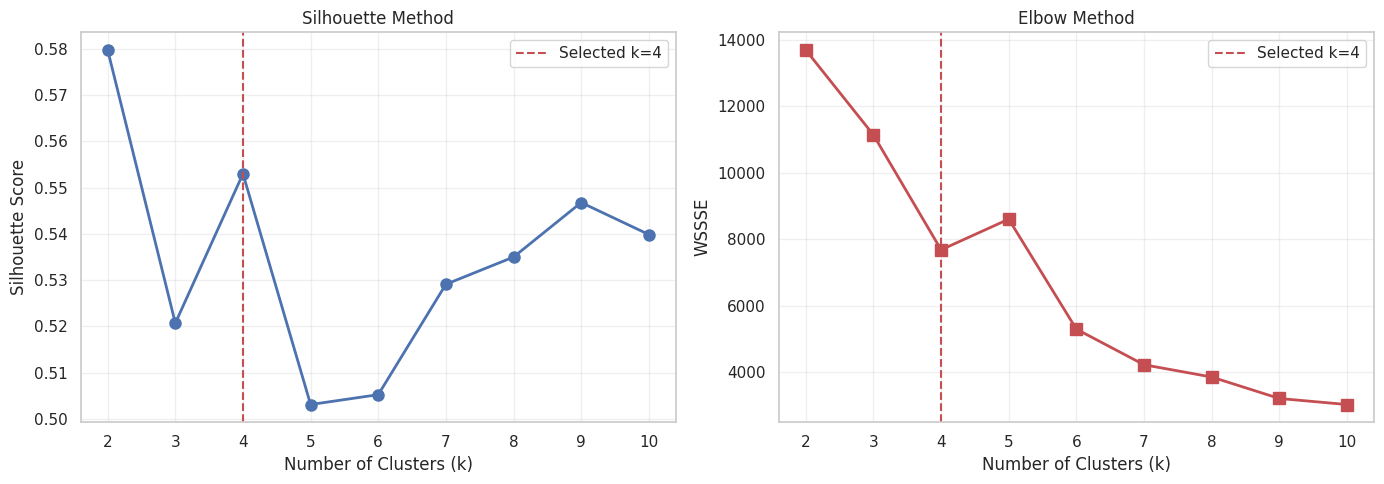

In [16]:
print("\n" + "="*60)
print("PHASE 6: OPTIMAL K SELECTION (Elbow + Silhouette)")
print("="*60)

total_users = pca_data.count()
sample_fraction = min(0.15, 5000.0 / total_users)
sampled = pca_data.sample(fraction=sample_fraction, seed=42).cache()
sample_count = sampled.count()
print(f"Mẫu đánh giá: {sample_count} users")

k_values = [2, 3, 4, 5, 6, 7, 8, 9, 10]
evaluator = ClusteringEvaluator(featuresCol="features", metricName="silhouette")

k_silhouette_scores = []
k_wssse_scores = []

for k in k_values:
    km = KMeans(featuresCol="features", k=k, seed=42, maxIter=20).fit(sampled)
    predictions = km.transform(sampled)
    sil = evaluator.evaluate(predictions)
    wssse = km.summary.trainingCost
    
    k_silhouette_scores.append(sil)
    k_wssse_scores.append(wssse)
    print(f"  k={k}: Silhouette={sil:.4f}, WSSSE={wssse:.2f}")

sampled.unpersist()

# Lựa chọn K tối ưu
def find_elbow_point(wssse_values, k_vals):
    """Tìm điểm cùi chỏ dựa trên khoảng cách hình học đã chuẩn hóa"""
    y = np.array(wssse_values)
    y_norm = (y - y.min()) / (y.max() - y.min() + 1e-10)  # Thêm epsilon tránh chia 0
    x = np.array(k_vals)
    x_norm = (x - x.min()) / (x.max() - x.min() + 1e-10)
    
    start_vec = np.array([x_norm[0], y_norm[0]])
    end_vec = np.array([x_norm[-1], y_norm[-1]])
    main_vec = end_vec - start_vec
    
    max_dist = 0
    elbow_k = k_vals[1]  # Giá trị mặc định
    
    for i in range(1, len(k_vals) - 1):
        point_vec = np.array([x_norm[i], y_norm[i]])
        # Tính khoảng cách từ điểm đến đường thẳng
        cross = np.abs(np.cross(main_vec, point_vec - start_vec))
        dist = cross / (np.linalg.norm(main_vec) + 1e-10)
        if dist > max_dist:
            max_dist = dist
            elbow_k = k_vals[i]
    return elbow_k

def find_local_peaks(scores, k_vals):
    """Tìm các đỉnh cục bộ (local maxima) của biểu đồ Silhouette"""
    peaks = []
    for i in range(1, len(scores) - 1):
        if scores[i] > scores[i-1] and scores[i] > scores[i+1]:
            peaks.append(k_vals[i])
    return peaks

# 1. Tính toán các điểm K tiềm năng
elbow_k = find_elbow_point(k_wssse_scores, k_values)
sil_peaks = find_local_peaks(k_silhouette_scores, k_values)

# Bỏ qua k=2 (thường có Silhouette cao nhất nhưng quá chung chung cho Business Persona)
valid_indices = [i for i, k in enumerate(k_values) if k >= 3]
best_sil_k = k_values[valid_indices[np.argmax([k_silhouette_scores[i] for i in valid_indices])]]

# 2. Logic kết hợp (Consensus Logic) thông minh
optimal_k = elbow_k
elbow_idx = k_values.index(elbow_k)

print(f"\nPhân tích K tối ưu:")
print(f"  - Elbow method đề xuất: k={elbow_k}")
print(f"  - Silhouette cao nhất (k>=3): k={best_sil_k} (score={max([k_silhouette_scores[i] for i in valid_indices]):.4f})")
print(f"  - Các đỉnh cục bộ của Silhouette: {sil_peaks if sil_peaks else 'Không có'}")

# Kiểm tra xem elbow_k có phải là "đáy cục bộ" của Silhouette không?
is_trough = False
if 0 < elbow_idx < len(k_silhouette_scores) - 1:
    if k_silhouette_scores[elbow_idx] < k_silhouette_scores[elbow_idx - 1] and \
       k_silhouette_scores[elbow_idx] < k_silhouette_scores[elbow_idx + 1]:
        is_trough = True

# Điều chỉnh nếu Elbow rơi vào điểm xấu
if is_trough:
    print(f"  -> Lưu ý: K={elbow_k} rơi vào điểm đáy của Silhouette.")
    # Chọn đỉnh lân cận tốt nhất (k-1 hoặc k+1)
    neighbor_ks = [k_values[elbow_idx - 1], k_values[elbow_idx + 1]]
    optimal_k = max(neighbor_ks, key=lambda k: k_silhouette_scores[k_values.index(k)])
    print(f"  -> Đã dịch chuyển Optimal K sang {optimal_k} để đảm bảo chất lượng cụm.")
    
elif elbow_k not in sil_peaks and sil_peaks:
    # Nếu Elbow không phải đáy, nhưng có một đỉnh Silhouette sát bên cạnh (cách 1 step)
    closest_peak = min(sil_peaks, key=lambda p: abs(p - elbow_k))
    if abs(closest_peak - elbow_k) == 1:
        # Nếu đỉnh lân cận đó có điểm cao hơn đáng kể (> 0.02), ưu tiên chọn đỉnh
        if k_silhouette_scores[k_values.index(closest_peak)] > k_silhouette_scores[elbow_idx] + 0.02:
            optimal_k = closest_peak
            print(f"  -> Đã dịch chuyển Optimal K sang đỉnh lân cận {optimal_k} để tối ưu ranh giới cụm.")

# Đảm bảo giới hạn thực tế (Business constraints: chia từ 3 đến 8 cụm)
optimal_k = max(3, min(optimal_k, 8))

print(f"\nSELECTED OPTIMAL K: {optimal_k}")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(k_values, k_silhouette_scores, 'bo-', linewidth=2, markersize=8)
axes[0].axvline(x=optimal_k, color='r', linestyle='--', label=f'Selected k={optimal_k}')
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Silhouette Score')
axes[0].set_title('Silhouette Method')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(k_values, k_wssse_scores, 'rs-', linewidth=2, markersize=8)
axes[1].axvline(x=optimal_k, color='r', linestyle='--', label=f'Selected k={optimal_k}')
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('WSSSE')
axes[1].set_title('Elbow Method')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 9. Đánh Giá & So Sánh Thuật Toán

> Chạy thử và so sánh độ hiệu quả (Silhouette Score, Thời gian chạy) của 3 thuật toán phổ biến:
> 1. **K-Means**
> 2. **Bisecting K-Means**
> 3. **Gaussian Mixture Model (GMM)**


In [17]:
print("\n" + "="*60)
print("PHASE 7: COMPARATIVE ALGORITHM EVALUATION")
print("="*60)

sampled_compare = pca_data.sample(fraction=min(0.15, 5000.0/total_users), seed=42).cache()

algorithms = {
    "K-Means": KMeans(featuresCol="features", k=optimal_k, seed=42, maxIter=20),
    "Bisecting K-Means": BisectingKMeans(featuresCol="features", k=optimal_k, seed=42, maxIter=20),
    "GMM": GaussianMixture(featuresCol="features", k=optimal_k, seed=42, maxIter=20)
}

comparison_results = []

for algo_name, algo in algorithms.items():
    print(f"\n>>> {algo_name}")
    start_time = time.time()
    
    model = algo.fit(sampled_compare)
    predictions = model.transform(sampled_compare)
    sil = evaluator.evaluate(predictions)
    runtime = time.time() - start_time
    
    if algo_name in ["K-Means", "Bisecting K-Means"]:
        wssse = model.summary.trainingCost
    else:
        wssse = -model.summary.logLikelihood
    
    comparison_results.append({
        'algorithm': algo_name,
        'silhouette_score': sil,
        'wssse': wssse,
        'runtime_seconds': runtime
    })
    
    print(f"  Silhouette: {sil:.4f}, Runtime: {runtime:.2f}s")

sampled_compare.unpersist()

comparison_df = pd.DataFrame(comparison_results)
best_algo_row = comparison_df.loc[comparison_df['silhouette_score'].idxmax()]
best_algo = best_algo_row['algorithm']
best_silhouette = best_algo_row['silhouette_score']

print(f"\nBest algorithm: {best_algo} (Silhouette={best_silhouette:.4f})")


PHASE 7: COMPARATIVE ALGORITHM EVALUATION

>>> K-Means


  Silhouette: 0.5530, Runtime: 84.97s

>>> Bisecting K-Means


  Silhouette: 0.5515, Runtime: 152.43s

>>> GMM


  Silhouette: 0.3846, Runtime: 88.78s

Best algorithm: K-Means (Silhouette=0.5530)


10. TRAINING FINAL MODEL

In [18]:
print("\n" + "="*60)
print("PHASE 8: FINAL TRAINING WITH OPTIMAL CONFIGURATION")
print("="*60)

print(f"Training {best_algo} với k={optimal_k} trên toàn bộ dữ liệu...")
start_time = time.time()

if best_algo == "K-Means":
    final_model = KMeans(featuresCol="features", predictionCol="cluster", 
                         k=optimal_k, seed=42, maxIter=30).fit(pca_data)
elif best_algo == "Bisecting K-Means":
    final_model = BisectingKMeans(featuresCol="features", predictionCol="cluster",
                                   k=optimal_k, seed=42, maxIter=30).fit(pca_data)
else:
    final_model = GaussianMixture(featuresCol="features", predictionCol="cluster",
                                   k=optimal_k, seed=42, maxIter=30).fit(pca_data)

predictions = final_model.transform(pca_data)
final_runtime = time.time() - start_time

final_silhouette = ClusteringEvaluator(featuresCol="features", predictionCol="cluster",
                                        metricName="silhouette").evaluate(predictions)
print(f"Final Silhouette: {final_silhouette:.4f}")
print(f"Training time: {final_runtime:.2f}s")



PHASE 8: FINAL TRAINING WITH OPTIMAL CONFIGURATION
Training K-Means với k=4 trên toàn bộ dữ liệu...


Final Silhouette: 0.4988
Training time: 128.94s


## 12. Gắn Nhãn & Đánh Giá Persona (Cluster Profiling)

> Tổng hợp thống kê của từng cụm, sau đó xây dựng chân dung người dùng cụ thể:
> - Cấp độ tương tác (Super/Active/Light).
> - Khung giờ ưa thích (Night Owl/Early Bird).
> - Hành vi chọn lọc bài (Selective/Critical/Passive).
> - Mức độ sâu của phiên nghe (Deep Session/Shallow Session).


In [19]:
print("\n" + "="*60)
print("PHASE 10: CLUSTER PROFILING & LABELING")
print("="*60)

cluster_profile = predictions.groupBy("cluster").agg(
    F.count("user_id").alias("user_count"),
    F.avg("total_listens").alias("avg_total_listens"),
    F.avg("daily_listen_rate").alias("avg_daily_rate"),
    F.avg("avg_tracks_per_session").alias("avg_session_depth"),
    F.avg("artist_entropy").alias("avg_artist_entropy"),
    F.avg("time_entropy").alias("avg_time_entropy"),
    F.avg("night_ratio").alias("avg_night_ratio"),
    F.avg("total_sessions").alias("avg_total_sessions")
).orderBy("cluster").toPandas()

# Thêm skip_rate nếu có
if 'skip_rate' in predictions.columns:
    skip_profile = predictions.groupBy("cluster").agg(F.avg("skip_rate").alias("avg_skip_rate")).toPandas()
    cluster_profile = cluster_profile.merge(skip_profile, on="cluster")

print("Chi tiết các cụm:")
print(cluster_profile.to_string())

def assign_label_enhanced(row, df):
    # 1. Mức độ active — dùng ngưỡng cứng, tránh bị lệch khi ít cluster
    total = row['avg_total_listens']
    if total > 10000:
        eng = "Super"
    elif total > 1000:
        eng = "Active"
    elif total > 100:
        eng = "Moderate"
    else:
        eng = "Light"
    
    # 2. Skip rate — kiểm tra nếu toàn 0 thì không phân biệt được
    if 'avg_skip_rate' in row.index and df['avg_skip_rate'].max() > 0:
        if row['avg_skip_rate'] > df['avg_skip_rate'].quantile(0.75):
            behavior = "Critical"
        elif row['avg_skip_rate'] > df['avg_skip_rate'].median():
            behavior = "Selective"
        else:
            behavior = "Passive"
    else:
        behavior = "N/A"  # không có dữ liệu skip
    
    # 3. Thời gian
    if row['avg_night_ratio'] > 0.35:
        ptime = "Night Owl"
    elif row['avg_night_ratio'] < 0.1:
        ptime = "Early Bird"
    else:
        ptime = "Mixed Time"
    
    # 4. Độ đa dạng — dùng ngưỡng cứng theo giá trị entropy thực tế
    entropy = row['avg_artist_entropy']
    if entropy > 5.0:
        div = "Explorer"
    elif entropy > 2.5:
        div = "Moderate"
    else:
        div = "Loyalist"
    
    # 5. Chiều sâu phiên nghe
    depth_val = row['avg_session_depth']
    if depth_val > 20:
        depth = "Deep Session"
    elif depth_val > 8:
        depth = "Normal Session"
    else:
        depth = "Shallow Session"
    
    return f"{eng} {ptime} {div} - {behavior} ({depth})"


cluster_profile['user_type'] = cluster_profile.apply(
    lambda r: assign_label_enhanced(r, cluster_profile), axis=1
)
label_map = dict(zip(cluster_profile['cluster'], cluster_profile['user_type']))

print("\nNhãn các cụm:")
for c, l in label_map.items():
    print(f"  Cluster {c}: {l}")


PHASE 10: CLUSTER PROFILING & LABELING


Chi tiết các cụm:
   cluster  user_count  avg_total_listens  avg_daily_rate  avg_session_depth  avg_artist_entropy  avg_time_entropy  avg_night_ratio  avg_total_sessions  avg_skip_rate
0        0        5935          13.423083        5.308912           4.298007            1.392395          1.013736         0.248803            3.139174            0.0
1        1       16391         736.046428       20.786048           9.838706            5.591385          3.597015         0.227747           83.384113            0.0
2        2          18       27122.722222      440.486404        3745.057843            6.833537          4.582828         0.294834           10.611111            0.0
3        3        6427       22657.440485       63.462069          26.397446            8.051820          4.159709         0.252226         1515.004668            0.0

Nhãn các cụm:
  Cluster 0: Light Mixed Time Loyalist - N/A (Shallow Session)
  Cluster 1: Moderate Mixed Time Explorer - N/A (Normal Session)
  Cl

## 13. Khám Phá Quy Luật bằng FP-Growth

> Chạy thuật toán **FP-Growth** cho từng cụm người dùng nhằm tìm ra các luật kết hợp (Association Rules) ẩn sâu trong nhóm các thuộc tính hành vi.


In [20]:
print("\n" + "="*60)
print("PHASE 11: FP-GROWTH KNOWLEDGE DISCOVERY")
print("="*60)

# Lấy dữ liệu cho FP-Growth (vẫn là PySpark DataFrame)
fp_spark = predictions.select(
    "user_id", "cluster",
    "total_listens", "skip_rate", "night_ratio", "artist_entropy",
    "avg_tracks_per_session"
)

# ---- Discretize bằng PySpark when/otherwise (KHÔNG dùng pd.cut trên Spark DF) ----
fp_spark = fp_spark \
    .withColumn("listen_level",
        F.when(F.col("total_listens") <= 500, "light")
         .when(F.col("total_listens") <= 2000, "medium")
         .otherwise("heavy")) \
    .withColumn("skip_level",
        F.when(F.col("skip_rate") <= 0.1, "passive")
         .when(F.col("skip_rate") <= 0.3, "selective")
         .otherwise("critical")) \
    .withColumn("night_level",
        F.when(F.col("night_ratio") <= 0.15, "day")
         .when(F.col("night_ratio") <= 0.35, "mixed")
         .otherwise("night_owl")) \
    .withColumn("diversity_level",
        F.when(F.col("artist_entropy") <= 1.5, "loyalist")
         .when(F.col("artist_entropy") <= 3.0, "moderate")
         .otherwise("explorer")) \
    .withColumn("session_level",
        F.when(F.col("avg_tracks_per_session") <= 5, "shallow")
         .when(F.col("avg_tracks_per_session") <= 15, "normal")
         .otherwise("deep"))

# Tạo cột items (array) bằng PySpark — không dùng fp_data.apply()
fp_spark = fp_spark.withColumn("items", F.array(
    F.concat(F.lit("listen_"), F.col("listen_level")),
    F.concat(F.lit("skip_"), F.col("skip_level")),
    F.concat(F.lit("time_"), F.col("night_level")),
    F.concat(F.lit("diversity_"), F.col("diversity_level")),
    F.concat(F.lit("session_"), F.col("session_level"))
))

# Lấy danh sách cluster_id từ Spark — không dùng .unique() của pandas
cluster_ids = [row['cluster'] for row in fp_spark.select("cluster").distinct().collect()]

# Chạy FP-Growth cho từng cluster
all_rules = []

for cluster_id in sorted(cluster_ids):
    cluster_name = label_map.get(cluster_id, f"Cluster_{cluster_id}")
    
    # Filter bằng PySpark (không dùng pandas indexing)
    basket = fp_spark.filter(F.col("cluster") == cluster_id).select("user_id", "items")
    n_users = basket.count()
    
    print(f"\n  Cluster {cluster_id}: {cluster_name} ({n_users} users)")
    
    if n_users < 50:
        print("    Bỏ qua - quá ít user")
        continue
    
    # Điều chỉnh minSupport theo kích thước cụm
    min_sup = 0.05 if n_users > 1000 else (0.08 if n_users > 200 else 0.12)
    min_conf = 0.6
    
    # FP-Growth
    fp = FPGrowth(itemsCol="items", minSupport=min_sup,
                  minConfidence=min_conf, numPartitions=10)
    model = fp.fit(basket)
    rules = model.associationRules
    
    n_rules = rules.count()
    print(f"    Tìm được {n_rules} luật")
    
    if n_rules > 0:
        rules_pd = rules.dropDuplicates(["antecedent", "consequent"]) \
                    .orderBy(F.col("lift").desc()) \
                    .toPandas()

        rules_pd['cluster'] = cluster_id
        rules_pd['cluster_name'] = cluster_name
        all_rules.append(rules_pd)
        
        # Hiển thị top 3 luật
        for _, row in rules_pd.head(3).iterrows():
            ant = '+'.join(row['antecedent'][:2])
            cons = ','.join(row['consequent'][:1])
            print(f"      {ant} → {cons} (lift={row['lift']:.2f})")

# Sửa phần cuối cell FP-Growth
if all_rules:
    all_rules_df = pd.concat(all_rules, ignore_index=True)
    os.makedirs("/kaggle/working/saved_model", exist_ok=True)  # ← thêm dòng này
    all_rules_df.to_csv('/kaggle/working/saved_model/fp_growth_rules.csv', index=False)
    print(f"\nLưu {len(all_rules_df)} luật FP-Growth vào fp_growth_rules.csv")
else:
    print("\nKhông tìm được luật FP-Growth nào")




PHASE 11: FP-GROWTH KNOWLEDGE DISCOVERY



  Cluster 0: Light Mixed Time Loyalist - N/A (Shallow Session) (5935 users)


    Tìm được 196 luật
      time_day+session_shallow → diversity_loyalist (lift=1.21)
      time_day+session_shallow → diversity_loyalist (lift=1.21)
      time_day+session_shallow → diversity_loyalist (lift=1.21)



  Cluster 1: Moderate Mixed Time Explorer - N/A (Normal Session) (16391 users)


    Tìm được 177 luật
      session_shallow+time_day → listen_light (lift=1.73)
      session_shallow+time_day → listen_light (lift=1.73)
      session_shallow+time_day → listen_light (lift=1.71)



  Cluster 2: Super Mixed Time Explorer - N/A (Deep Session) (18 users)
    Bỏ qua - quá ít user



  Cluster 3: Super Mixed Time Explorer - N/A (Deep Session) (6427 users)


    Tìm được 157 luật
      time_mixed+session_deep → listen_heavy (lift=1.04)
      time_mixed+session_deep → listen_heavy (lift=1.04)
      time_mixed+session_deep → listen_heavy (lift=1.04)

Lưu 530 luật FP-Growth vào fp_growth_rules.csv


14. LƯU KẾT QUẢ CHO STREAMLIT

In [21]:
print("\n" + "="*60)
print("PHASE 11: SAVING RESULTS FOR STREAMLIT DEMO")
print("="*60)

import os
import pickle
import json
from pyspark.sql import functions as F

os.makedirs("/kaggle/working/saved_model", exist_ok=True)

# Ensure variable exists
if 'soft_clustering_data' not in globals():
    soft_clustering_data = None

# ======================
# Save models
# ======================
pca_model.write().overwrite().save("/kaggle/working/saved_model/pca_model")
scaler_model.write().overwrite().save("/kaggle/working/saved_model/scaler_model")
final_model.write().overwrite().save(
    f"/kaggle/working/saved_model/clustering_model_{best_algo.lower().replace(' ', '_')}"
)

# ======================
# Save artifacts
# ======================
model_artifacts = {
    "best_algorithm": best_algo,
    "optimal_k": optimal_k,
    "silhouette_score": float(final_silhouette),
    "cluster_labels": label_map,
    "feature_cols": feature_cols,
    "feature_descriptions": feature_descriptions,
    "k_pca": k_pca,
    "pca_explained_variance": float(cumulative_var_full[k_pca - 1]),
    "algorithm_comparison": comparison_results,
    "has_soft_clustering": (best_algo == "GMM")
}

with open("/kaggle/working/saved_model/model_artifacts.pkl", "wb") as f:
    pickle.dump(model_artifacts, f)

# ======================
# Save metadata
# ======================
metadata = {
    "total_users": pca_data.count(),
    "clusters": optimal_k,
    "silhouette_score": float(final_silhouette),
    "best_algorithm": best_algo,
    "pca_components": k_pca,
    "pca_explained_variance": float(cumulative_var_full[k_pca - 1]),
    "user_types": list(label_map.values()),
    "feature_descriptions": feature_descriptions,
    "enhanced_features": [
        "Skip Rate (Quality behavior) - Phan biet Critical/Selective/Passive listener",
        "Session Analysis - Do chieu sau engagement (Deep/Normal/Shallow Session)",
        "Soft Clustering (GMM) - Phat hien mixed personas",
        "Shannon Entropy - Do do da dang nghe si va thoi gian"
    ]
}

with open("/kaggle/working/saved_model/metadata.json", "w", encoding="utf-8") as f:
    json.dump(metadata, f, indent=2, ensure_ascii=False)

# ======================
# Save clustering results
# ======================
label_rows = [(int(k), v) for k, v in label_map.items()]
label_df = spark.createDataFrame(label_rows, ["cluster", "user_type"])

final_results = predictions.join(label_df, on="cluster", how="left")

final_results.select(
    "user_id",
    "cluster",
    "user_type",
    "total_listens",
    "daily_listen_rate",
    "avg_tracks_per_session",
    F.col("artist_entropy").alias("artist_diversity"),
    F.col("night_ratio").alias("night_listen_ratio")
).write.mode("overwrite").parquet("/kaggle/working/saved_model/user_clusters.parquet")

# ======================
# Save soft clustering (if exists)
# ======================
if soft_clustering_data is not None:
    soft_clustering_data.write.mode("overwrite").parquet(
        "/kaggle/working/saved_model/soft_clustering_results.parquet"
    )

# ======================
# Save comparison results
# ======================
comparison_df.to_csv(
    "/kaggle/working/saved_model/algorithm_comparison.csv",
    index=False
)

print("All models and results saved successfully!")


PHASE 11: SAVING RESULTS FOR STREAMLIT DEMO


All models and results saved successfully!


15. TỔNG KẾT

In [22]:
print("\n" + "="*65)
print("TỔNG KẾT MODULE 1 — USER PERSONA CLUSTERING")
print("="*65)

print(f"""
KẾT QUẢ CHÍNH:
   - Thuật toán tốt nhất: {best_algo}
   - Số cụm tối ưu: {optimal_k}
   - Silhouette Score: {final_silhouette:.4f}
   - PCA variance: {cumulative_var_full[k_pca-1]*100:.1f}% với {k_pca} chiều""")

print("="*65)
print("MODULE 1 HOÀN THÀNH! CHUẨN BỊ CHO STREAMLIT DEMO")


TỔNG KẾT MODULE 1 — USER PERSONA CLUSTERING

KẾT QUẢ CHÍNH:
   - Thuật toán tốt nhất: K-Means
   - Số cụm tối ưu: 4
   - Silhouette Score: 0.4988
   - PCA variance: 67.6% với 3 chiều
MODULE 1 HOÀN THÀNH! CHUẨN BỊ CHO STREAMLIT DEMO


In [23]:
!zip -r /kaggle/working/saved_model.zip /kaggle/working/saved_model/
print("Done! Tải file saved_model.zip từ Output panel bên phải")

  adding: kaggle/working/saved_model/ (stored 0%)
  adding: kaggle/working/saved_model/user_clusters.parquet/ (stored 0%)
  adding: kaggle/working/saved_model/user_clusters.parquet/._SUCCESS.crc (stored 0%)
  adding: kaggle/working/saved_model/user_clusters.parquet/part-00000-b7db6f72-1b82-4f9b-ae9d-8db770e5d91a-c000.snappy.parquet (deflated 11%)
  adding: kaggle/working/saved_model/user_clusters.parquet/_SUCCESS (stored 0%)
  adding: kaggle/working/saved_model/user_clusters.parquet/.part-00000-b7db6f72-1b82-4f9b-ae9d-8db770e5d91a-c000.snappy.parquet.crc (stored 0%)
  adding: kaggle/working/saved_model/model_artifacts.pkl (deflated 38%)
  adding: kaggle/working/saved_model/pca_model/ (stored 0%)
  adding: kaggle/working/saved_model/pca_model/data/ (stored 0%)
  adding: kaggle/working/saved_model/pca_model/data/part-00000-6f7fc6c0-38de-49ac-8e01-d0749f4725d9-c000.snappy.parquet (deflated 64%)
  adding: kaggle/working/saved_model/pca_model/data/._SUCCESS.crc (stored 0%)
  adding: kaggle/